# 27 — Assembly101 Qwen Visual-Input Integrity Audit

Notebooks 25 and 26 produced unexpectedly weak pseudo-text results. This
notebook determines whether that is caused by a pipeline error or by the
limited quality of the generated captions.

It is a **diagnostic notebook**, not another ablation. It does not modify
notebooks 24--26, does not retrain a model, and does not regenerate the
complete validation split. It performs:

1. a structural, temporal, frame-index, and class-mapping audit on all 120
   validation sequences;
2. a temporal-shift sweep against validation annotations;
3. exact-frame visual inspection for two preselected sequences;
4. processor introspection proving how many images Qwen receives;
5. deterministic real / reversed / black-frame counterfactuals;
6. an automatic decision specifying which earlier notebooks, if any,
   must be corrected and rerun.

Only validation data are accessed. The test split remains locked.


## Decision map

| Failed check | Interpretation | Notebook(s) to correct |
|---|---|---|
| N15/N24 time agreement | temporal alignment error | 15, 24, then rerun 25--26 |
| Stored N24 frame indices | sampling/indexing error | 24, then rerun 25--26 |
| Class ID ↔ action string | mapping/prototype error | 15/18/24, then 25--26 |
| Processor does not expose 16 images | multimodal packaging error | 24, then 25--26 |
| Real output equals black-frame output | visual input is ignored | 24, then 25--26 |
| Strong non-zero temporal shift | frame order/alignment error | 24, then 25--26 |
| All integrity checks pass | no pipeline bug found | keep 15/18/24--26; improve the method in a new notebook |

Passing the integrity audit does not mean that Qwen captions are good.
It means the low score is a model/method result rather than an obvious
data-routing error.


## 1. Mount Google Drive


In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)


Mounted at /content/drive


## 2. Install dependencies

This uses the same Qwen model family and processor API as notebook 24.
If Colab asks for a runtime restart after installation, restart once and
continue from the imports cell.


In [2]:
# %pip install -q -U \
#   "transformers>=5.14.0,<6" \
#   accelerate safetensors \
#   "huggingface_hub[hf_xet]" \
#   decord pillow tqdm

## 3. Imports, reproducibility, and hardware


In [3]:
from pathlib import Path
from datetime import datetime, timezone

import difflib
import gc
import hashlib
import json
import os
import platform
import random
import shutil
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import transformers
from PIL import Image, ImageOps
from decord import VideoReader, cpu
from huggingface_hub import (
    get_token,
    hf_hub_download,
    login,
    notebook_login,
)
from tqdm.auto import tqdm
from transformers import AutoModelForMultimodalLM, AutoProcessor

os.environ["TOKENIZERS_PARALLELISM"] = "false"
pd.set_option("display.max_columns", 180)
pd.set_option("display.max_colwidth", 240)

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if not torch.cuda.is_available():
    raise RuntimeError(
        "Select Runtime -> Change runtime type -> GPU before notebook 27."
    )

GPU_NAME = torch.cuda.get_device_name(0)
GPU_TOTAL_GIB = torch.cuda.get_device_properties(0).total_memory / 1024**3
MODEL_DTYPE = (
    torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
)

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("GPU:", GPU_NAME)
print("GPU memory:", f"{GPU_TOTAL_GIB:.2f} GiB")
print("Selected dtype:", MODEL_DTYPE)


Python: 3.12.13
PyTorch: 2.11.0+cu128
Transformers: 5.15.0
GPU: Tesla T4
GPU memory: 14.56 GiB
Selected dtype: torch.bfloat16


## 4. Locked configuration and paths


In [4]:
TARGET_SPLIT = "validation"
TEST_ACCESSED = False
EXPECTED_SEQUENCES = 120
EXPECTED_CLASSES = 202
NUM_TEMPORAL_STEPS = 16
FRAME_SIDE = 224
PROCESSOR_MAX_IMAGE_PIXELS = FRAME_SIDE * FRAME_SIDE
JPEG_QUALITY = 92
MAX_NEW_TOKENS = 768
MAX_DOWNLOAD_ATTEMPTS = 3
RETRY_SLEEP_SECONDS = 10
NUM_VISUAL_AUDIT_SEQUENCES = 2
DELETE_AUDIT_DOWNLOADS = True

QWEN_MODEL_ID = "Qwen/Qwen3.5-2B"
REPO_ID = "cvml-nus/assembly101"
REPO_TYPE = "dataset"

DRIVE_ROOT = Path("/content/drive/MyDrive/mmf_tas_lab_data")
ASSEMBLY_ROOT = DRIVE_ROOT / "assembly101"
MSTCN_ROOT = (
    DRIVE_ROOT
    / "text_assisted_tas"
    / "assembly101"
    / "coarse_mstcn_format"
)
FEATURE_ROOT = MSTCN_ROOT / "streaming_visual_features_v1"
CLIP_ROOT = FEATURE_ROOT / "clip_vitb16"

SEQUENCE_MANIFEST_PATH = (
    MSTCN_ROOT / "procedurevrl_extraction_manifest_v1.csv"
)
RECORDING_MANIFEST_PATH = (
    MSTCN_ROOT / "recording_download_manifest_v1.csv"
)
REMOTE_SIZE_INVENTORY_PATH = (
    MSTCN_ROOT / "v1_download" / "remote_size_inventory_v1.csv"
)
NOTEBOOK14_SUMMARY_PATH = (
    MSTCN_ROOT / "v1_download" / "assembly101_v1_download_summary.json"
)
TEMPORAL_ALIGNMENT_PATH = (
    FEATURE_ROOT / "manifests" / "temporal_alignment_manifest.csv"
)
GT_DIR = CLIP_ROOT / "groundTruth"
SPLIT_DIR = CLIP_ROOT / "splits"
MAPPING_PATH = CLIP_ROOT / "mapping.txt"

NOTEBOOK24_ROOT = (
    FEATURE_ROOT
    / "runs"
    / "24_qwen35_pseudotext"
    / "qwen35_2b_closedset_temporal_v1"
)
NOTEBOOK24_SUMMARY = NOTEBOOK24_ROOT / "final_summary.json"
NOTEBOOK24_PROMPT = NOTEBOOK24_ROOT / "prompt.txt"
PARSED_PREDICTION_DIR = NOTEBOOK24_ROOT / "parsed_predictions"

NOTEBOOK25_SUMMARY = (
    FEATURE_ROOT
    / "runs"
    / "25_qwen_pseudotext_teacher_validation"
    / "final_summary.json"
)
NOTEBOOK26_SUMMARY = (
    FEATURE_ROOT
    / "runs"
    / "26_qwen_caption_embedding_ablation"
    / "final_summary.json"
)

OUT_ROOT = FEATURE_ROOT / "runs" / "27_qwen_visual_input_integrity_audit"
ARTIFACT_ROOT = OUT_ROOT / "artifacts"
COUNTERFACTUAL_ROOT = OUT_ROOT / "counterfactuals"
TEMP_FRAME_ROOT = Path("/content/qwen27_integrity_frames")

for path in [OUT_ROOT, ARTIFACT_ROOT, COUNTERFACTUAL_ROOT, TEMP_FRAME_ROOT]:
    path.mkdir(parents=True, exist_ok=True)

if TARGET_SPLIT != "validation" or TEST_ACCESSED:
    raise RuntimeError("Notebook 27 is locked to validation-only diagnostics.")

CENTER_POSITIONS = (
    np.arange(NUM_TEMPORAL_STEPS, dtype=np.float64) + 0.5
) / NUM_TEMPORAL_STEPS

print("OUT_ROOT:", OUT_ROOT)
print("Temporal centers:", CENTER_POSITIONS.tolist())


OUT_ROOT: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/27_qwen_visual_input_integrity_audit
Temporal centers: [0.03125, 0.09375, 0.15625, 0.21875, 0.28125, 0.34375, 0.40625, 0.46875, 0.53125, 0.59375, 0.65625, 0.71875, 0.78125, 0.84375, 0.90625, 0.96875]


## 5. Validate prerequisites and provenance


In [5]:
required_paths = {
    "sequence manifest": SEQUENCE_MANIFEST_PATH,
    "recording manifest": RECORDING_MANIFEST_PATH,
    "remote-size inventory": REMOTE_SIZE_INVENTORY_PATH,
    "notebook-14 summary": NOTEBOOK14_SUMMARY_PATH,
    "notebook-15 temporal alignment": TEMPORAL_ALIGNMENT_PATH,
    "validation ground truth": GT_DIR,
    "split bundles": SPLIT_DIR,
    "mapping": MAPPING_PATH,
    "notebook-24 summary": NOTEBOOK24_SUMMARY,
    "notebook-24 prompt": NOTEBOOK24_PROMPT,
    "notebook-24 parsed outputs": PARSED_PREDICTION_DIR,
    "notebook-25 summary": NOTEBOOK25_SUMMARY,
    "notebook-26 summary": NOTEBOOK26_SUMMARY,
}

for name, path in required_paths.items():
    print(f"{name}: exists={path.exists()} -> {path}")
    if not path.exists():
        raise FileNotFoundError(f"Missing prerequisite: {name}: {path}")

notebook14 = json.loads(NOTEBOOK14_SUMMARY_PATH.read_text(encoding="utf-8"))
notebook24 = json.loads(NOTEBOOK24_SUMMARY.read_text(encoding="utf-8"))
notebook25 = json.loads(NOTEBOOK25_SUMMARY.read_text(encoding="utf-8"))
notebook26 = json.loads(NOTEBOOK26_SUMMARY.read_text(encoding="utf-8"))
original_prompt = NOTEBOOK24_PROMPT.read_text(encoding="utf-8").strip()
prompt_sha256 = hashlib.sha256(original_prompt.encode("utf-8")).hexdigest()

if notebook24.get("status") != "completed":
    raise RuntimeError("Notebook 24 is not complete.")
if notebook24.get("target_split") != "validation":
    raise RuntimeError("Notebook 24 is not a validation run.")
if notebook24.get("completed_cohort_sequences") != EXPECTED_SEQUENCES:
    raise RuntimeError("Notebook 24 does not contain 120 validation sequences.")
if notebook24.get("ground_truth_loaded") is not False:
    raise RuntimeError("Notebook 24 unexpectedly reports ground-truth access.")
if notebook24.get("model_id") != QWEN_MODEL_ID:
    raise RuntimeError("Notebook 24 used a different Qwen model.")
if notebook24.get("prompt_sha256") != prompt_sha256:
    raise RuntimeError("Notebook 24 prompt file does not match its saved hash.")

if notebook25.get("status") != "completed":
    raise RuntimeError("Notebook 25 is not complete.")
if notebook25.get("data", {}).get("test_accessed") is not False:
    raise RuntimeError("Notebook 25 unexpectedly reports test access.")
if notebook26.get("status") != "completed":
    raise RuntimeError("Notebook 26 is not complete.")
if notebook26.get("data", {}).get("test_accessed") is not False:
    raise RuntimeError("Notebook 26 unexpectedly reports test access.")

PINNED_REVISION = str(notebook14["pinned_revision"])

provenance = {
    "notebook24_model": notebook24["model_id"],
    "notebook24_prompt_sha256": prompt_sha256,
    "notebook24_sequences": notebook24["completed_cohort_sequences"],
    "notebook25_test_accessed": notebook25["data"]["test_accessed"],
    "notebook26_test_accessed": notebook26["data"]["test_accessed"],
    "assembly101_revision": PINNED_REVISION,
}
print(json.dumps(provenance, indent=2))


sequence manifest: exists=True -> /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/procedurevrl_extraction_manifest_v1.csv
recording manifest: exists=True -> /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/recording_download_manifest_v1.csv
remote-size inventory: exists=True -> /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/v1_download/remote_size_inventory_v1.csv
notebook-14 summary: exists=True -> /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/v1_download/assembly101_v1_download_summary.json
notebook-15 temporal alignment: exists=True -> /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/manifests/temporal_alignment_manifest.csv
validation ground truth: exists=True -> /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_f

## 6. Load the official validation cohort and class mapping


In [6]:
def canonical_split(value):
    value = str(value).strip().lower()
    if value in {"val", "valid", "validation"}:
        return "validation"
    if value in {"test", "testing"}:
        return "test"
    if value in {"train", "training"}:
        return "train"
    return value


def read_nonempty_lines(path):
    return [
        line.strip()
        for line in Path(path).read_text(encoding="utf-8").splitlines()
        if line.strip()
    ]


def resolve_bundle(split_dir, split_name):
    split_dir = Path(split_dir)
    for candidate in [
        split_dir / f"{split_name}.bundle",
        split_dir / f"{split_name}.split1.bundle",
    ]:
        if candidate.exists():
            return candidate
    candidates = sorted(
        path
        for path in split_dir.glob("*.bundle")
        if split_name.lower() in path.name.lower()
        and ".partial." not in path.name.lower()
        and not path.name.lower().endswith(".partial.bundle")
    )
    if len(candidates) != 1:
        raise FileNotFoundError(
            f"Could not uniquely resolve {split_name}: {candidates}"
        )
    return candidates[0]


def load_mapping(path):
    id_to_label = {}
    label_to_id = {}
    for line in read_nonempty_lines(path):
        index_text, label = line.split(maxsplit=1)
        index = int(index_text)
        if index in id_to_label or label in label_to_id:
            raise ValueError(f"Duplicate mapping entry: {line}")
        id_to_label[index] = label
        label_to_id[label] = index
    return id_to_label, label_to_id


sequences = pd.read_csv(SEQUENCE_MANIFEST_PATH)
recordings = pd.read_csv(RECORDING_MANIFEST_PATH)
remote_sizes = pd.read_csv(REMOTE_SIZE_INVENTORY_PATH)
alignment = pd.read_csv(TEMPORAL_ALIGNMENT_PATH)
sequences["canonical_split"] = sequences["split"].map(canonical_split)

id_to_label, label_to_id = load_mapping(MAPPING_PATH)
VAL_BUNDLE = resolve_bundle(SPLIT_DIR, "val")
val_ids = [Path(line).stem for line in read_nonempty_lines(VAL_BUNDLE)]
val_sequences = sequences[
    sequences["canonical_split"] == TARGET_SPLIT
].copy()

if len(id_to_label) != EXPECTED_CLASSES:
    raise ValueError(f"Expected 202 classes, got {len(id_to_label)}.")
if set(id_to_label) != set(range(EXPECTED_CLASSES)):
    raise ValueError("Mapping IDs are not contiguous 0..201.")
if len(val_ids) != EXPECTED_SEQUENCES or len(set(val_ids)) != EXPECTED_SEQUENCES:
    raise ValueError("Official validation bundle must contain 120 unique IDs.")
if set(val_ids) != set(val_sequences["sequence_id"].astype(str)):
    raise RuntimeError("Validation bundle and sequence manifest disagree.")

print("Classes:", len(id_to_label))
print("Validation sequences:", len(val_ids))
print("Validation bundle:", VAL_BUNDLE)


Classes: 202
Validation sequences: 120
Validation bundle: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/clip_vitb16/splits/val.split1.bundle


## 7. Structural, temporal, frame-index, and mapping audit

Notebook 24 sampled frame times at the 16 bin centers. Notebook 15 saved
the corresponding centers and approximate absolute times. We compare the
independently saved records for every normal Qwen output. The single
explicitly repaired all-zero sequence is retained in the cohort but is
excluded from checks that require its unavailable frame metadata.


In [7]:
required_alignment_columns = {
    "sequence_id",
    "step_index",
    "normalized_center",
    "approximate_absolute_time_seconds",
    "action_label",
}
missing_alignment = required_alignment_columns - set(alignment.columns)
if missing_alignment:
    raise KeyError(f"Alignment manifest is missing: {sorted(missing_alignment)}")

alignment_by_sequence = {
    str(sequence_id): group.sort_values("step_index").reset_index(drop=True)
    for sequence_id, group in alignment.groupby("sequence_id")
}
sequence_by_id = val_sequences.set_index("sequence_id", drop=False)

audit_rows = []
prediction_rows = []

for sequence_id in tqdm(val_ids, desc="Audit N24 metadata"):
    metadata_path = PARSED_PREDICTION_DIR / f"{sequence_id}.json"
    if not metadata_path.exists():
        raise FileNotFoundError(metadata_path)

    metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
    sequence_row = sequence_by_id.loc[sequence_id]
    alignment_rows = alignment_by_sequence.get(sequence_id)
    is_fallback = bool(metadata.get("fallback_policy"))
    steps = sorted(metadata.get("steps", []), key=lambda row: int(row["step"]))

    expected_times = (
        float(sequence_row.clip_start_seconds)
        + CENTER_POSITIONS
        * (
            float(sequence_row.clip_end_seconds)
            - float(sequence_row.clip_start_seconds)
        )
    )

    structure_errors = []
    if metadata.get("sequence_id") != sequence_id:
        structure_errors.append("sequence_id")
    if canonical_split(metadata.get("split")) != TARGET_SPLIT:
        structure_errors.append("split")
    if metadata.get("model_id") != QWEN_MODEL_ID:
        structure_errors.append("model_id")
    if metadata.get("prompt_sha256") != prompt_sha256:
        structure_errors.append("prompt_sha256")
    if len(steps) != NUM_TEMPORAL_STEPS:
        structure_errors.append("step_count")
    if [int(step["step"]) for step in steps] != list(range(NUM_TEMPORAL_STEPS)):
        structure_errors.append("step_indices")
    if alignment_rows is None or len(alignment_rows) != NUM_TEMPORAL_STEPS:
        structure_errors.append("alignment_rows")

    mapping_mismatches = 0
    for step in steps:
        class_id = step.get("model_class_id")
        action_label = step.get("action_cls")
        match_method = str(step.get("match_method", ""))
        if class_id is None:
            predicted_id = -1
            if not (is_fallback or match_method == "zero_step_fallback"):
                mapping_mismatches += 1
        else:
            predicted_id = int(class_id)
            if (
                predicted_id not in id_to_label
                or id_to_label[predicted_id] != action_label
            ):
                mapping_mismatches += 1

        prediction_rows.append(
            {
                "sequence_id": sequence_id,
                "step_index": int(step["step"]),
                "predicted_class_id": predicted_id,
                "predicted_action": action_label,
                "is_fallback_sequence": is_fallback,
            }
        )

    has_frame_metadata = all(
        key in metadata
        for key in [
            "absolute_times_seconds",
            "frame_indices",
            "video_fps",
            "video_total_frames",
        ]
    )
    max_time_error = np.nan
    max_n15_time_error = np.nan
    max_center_error = np.nan
    max_frame_index_error = np.nan

    if has_frame_metadata:
        saved_times = np.asarray(
            metadata["absolute_times_seconds"], dtype=np.float64
        )
        saved_indices = np.asarray(metadata["frame_indices"], dtype=np.int64)
        if len(saved_times) != NUM_TEMPORAL_STEPS:
            structure_errors.append("absolute_time_count")
        if len(saved_indices) != NUM_TEMPORAL_STEPS:
            structure_errors.append("frame_index_count")

        if len(saved_times) == NUM_TEMPORAL_STEPS:
            max_time_error = float(np.max(np.abs(saved_times - expected_times)))
        if alignment_rows is not None and len(alignment_rows) == NUM_TEMPORAL_STEPS:
            n15_times = alignment_rows[
                "approximate_absolute_time_seconds"
            ].to_numpy(dtype=np.float64)
            n15_centers = alignment_rows[
                "normalized_center"
            ].to_numpy(dtype=np.float64)
            max_n15_time_error = float(np.max(np.abs(n15_times - expected_times)))
            max_center_error = float(np.max(np.abs(n15_centers - CENTER_POSITIONS)))

        if len(saved_indices) == NUM_TEMPORAL_STEPS:
            expected_indices = np.rint(
                expected_times * float(metadata["video_fps"])
            ).astype(np.int64)
            expected_indices = np.clip(
                expected_indices,
                0,
                int(metadata["video_total_frames"]) - 1,
            )
            max_frame_index_error = int(
                np.max(np.abs(saved_indices - expected_indices))
            )

    audit_rows.append(
        {
            "sequence_id": sequence_id,
            "recording_name": str(sequence_row.recording_name),
            "activity": str(sequence_row.get("activity", "")),
            "is_fallback_sequence": is_fallback,
            "has_frame_metadata": has_frame_metadata,
            "media_mode": str(metadata.get("media_mode", "")),
            "structure_errors": ";".join(structure_errors),
            "mapping_mismatches": mapping_mismatches,
            "max_expected_time_error_seconds": max_time_error,
            "max_n15_time_error_seconds": max_n15_time_error,
            "max_normalized_center_error": max_center_error,
            "max_frame_index_error": max_frame_index_error,
            "caption_unique_count": len(
                {str(step.get("caption", "")).strip() for step in steps}
            ),
        }
    )

audit_df = pd.DataFrame(audit_rows)
predictions_df = pd.DataFrame(prediction_rows)
regular_df = audit_df[~audit_df["is_fallback_sequence"]].copy()

audit_path = OUT_ROOT / "structural_temporal_audit.csv"
prediction_path = OUT_ROOT / "notebook24_hard_predictions.csv"
audit_df.to_csv(audit_path, index=False)
predictions_df.to_csv(prediction_path, index=False)

structural_passed = bool(
    len(audit_df) == EXPECTED_SEQUENCES
    and audit_df["structure_errors"].eq("").all()
)
temporal_alignment_passed = bool(
    regular_df["has_frame_metadata"].all()
    and regular_df["max_expected_time_error_seconds"].fillna(np.inf).max() < 1e-6
    and regular_df["max_n15_time_error_seconds"].fillna(np.inf).max() < 1e-6
    and regular_df["max_normalized_center_error"].fillna(np.inf).max() < 1e-12
)
frame_index_passed = bool(
    regular_df["max_frame_index_error"].fillna(np.inf).max() == 0
)
mapping_passed = bool(audit_df["mapping_mismatches"].sum() == 0)

structural_summary = {
    "validation_sequences": int(len(audit_df)),
    "regular_generated_sequences": int(len(regular_df)),
    "declared_fallback_sequences": int(audit_df["is_fallback_sequence"].sum()),
    "media_modes": {
        str(key): int(value)
        for key, value in audit_df["media_mode"].value_counts().items()
    },
    "structural_passed": structural_passed,
    "temporal_alignment_passed": temporal_alignment_passed,
    "frame_index_passed": frame_index_passed,
    "mapping_passed": mapping_passed,
    "mapping_mismatches": int(audit_df["mapping_mismatches"].sum()),
    "max_expected_time_error_seconds": float(
        regular_df["max_expected_time_error_seconds"].max()
    ),
    "max_n15_time_error_seconds": float(
        regular_df["max_n15_time_error_seconds"].max()
    ),
    "max_frame_index_error": int(regular_df["max_frame_index_error"].max()),
}
(OUT_ROOT / "structural_temporal_summary.json").write_text(
    json.dumps(structural_summary, indent=2), encoding="utf-8"
)

print(json.dumps(structural_summary, indent=2))
display(audit_df.head())


Audit N24 metadata:   0%|          | 0/120 [00:00<?, ?it/s]

{
  "validation_sequences": 120,
  "regular_generated_sequences": 119,
  "declared_fallback_sequences": 1,
  "media_modes": {
    "ordered_images": 120
  },
  "structural_passed": true,
  "temporal_alignment_passed": true,
  "frame_index_passed": true,
  "mapping_passed": true,
  "mapping_mismatches": 0,
  "max_expected_time_error_seconds": 0.0,
  "max_n15_time_error_seconds": 2.2737367544323206e-13,
  "max_frame_index_error": 0
}


,sequence_id,recording_name,activity,is_fallback_sequence,has_frame_metadata,media_mode,structure_errors,mapping_mismatches,max_expected_time_error_seconds,max_n15_time_error_seconds,max_normalized_center_error,max_frame_index_error,caption_unique_count
0,assembly_nusar-2021_action_both_9011-c03f_9011_user_id_2021-02-01_160239,nusar-2021_action_both_9011-c03f_9011_user_id_2021-02-01_160239,assembly,False,True,ordered_images,,0,0.0,5.684342e-14,0.0,0.0,6
1,assembly_nusar-2021_action_both_9012-c14b_9012_user_id_2021-02-01_164944,nusar-2021_action_both_9012-c14b_9012_user_id_2021-02-01_164944,assembly,False,True,ordered_images,,0,0.0,1.136868e-13,0.0,0.0,2
2,assembly_nusar-2021_action_both_9013-a28_9013_user_id_2021-02-02_134923,nusar-2021_action_both_9013-a28_9013_user_id_2021-02-02_134923,assembly,False,True,ordered_images,,0,0.0,2.842171e-14,0.0,0.0,7
3,assembly_nusar-2021_action_both_9013-c09c_9013_user_id_2021-02-24_113951,nusar-2021_action_both_9013-c09c_9013_user_id_2021-02-24_113951,assembly,False,True,ordered_images,,0,0.0,1.136868e-13,0.0,0.0,1
4,assembly_nusar-2021_action_both_9014-a23_9014_user_id_2021-02-02_142800,nusar-2021_action_both_9014-a23_9014_user_id_2021-02-02_142800,assembly,False,True,ordered_images,,0,0.0,5.684342e-14,0.0,0.0,1


## 8. Temporal-shift and reversal diagnostic


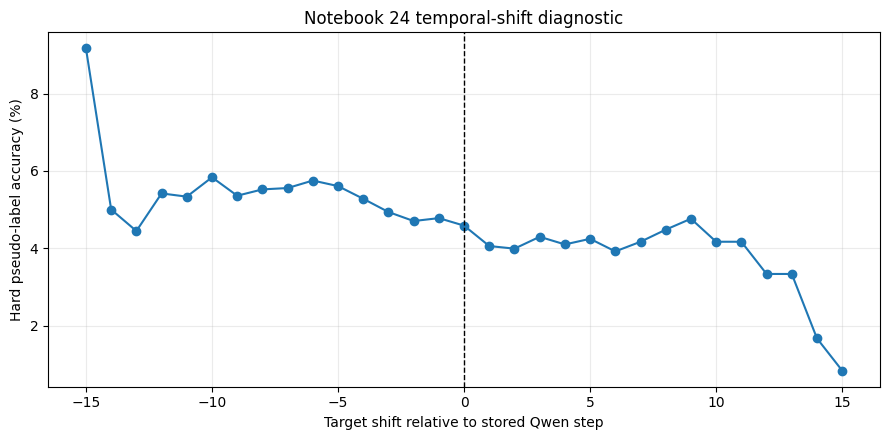

{
  "shift_zero_accuracy_percent": 4.583333333333333,
  "best_local_shift": -4,
  "best_local_accuracy_percent": 5.277777777777778,
  "best_local_minus_zero_points": 0.6944444444444446,
  "alert_threshold_points": 3.0,
  "shift_alert": false,
  "reversed_accuracy_percent": 4.791666666666667
}


In [8]:
target_by_sequence = {}
for sequence_id in val_ids:
    gt_path = GT_DIR / f"{sequence_id}.txt"
    labels = read_nonempty_lines(gt_path)
    if len(labels) != NUM_TEMPORAL_STEPS:
        raise ValueError(f"Expected 16 labels in {gt_path}, got {len(labels)}")
    unknown = sorted(set(labels) - set(label_to_id))
    if unknown:
        raise ValueError(f"Unknown ground-truth labels in {gt_path}: {unknown}")
    target_by_sequence[sequence_id] = np.asarray(
        [label_to_id[label] for label in labels], dtype=np.int64
    )

pred_by_sequence = {
    sequence_id: group.sort_values("step_index")[
        "predicted_class_id"
    ].to_numpy(dtype=np.int64)
    for sequence_id, group in predictions_df.groupby("sequence_id")
}

def shifted_accuracy(shift):
    correct = 0
    total = 0
    for sequence_id in val_ids:
        pred = pred_by_sequence[sequence_id]
        target = target_by_sequence[sequence_id]
        if shift >= 0:
            pred_view = pred[: NUM_TEMPORAL_STEPS - shift]
            target_view = target[shift:]
        else:
            pred_view = pred[-shift:]
            target_view = target[: NUM_TEMPORAL_STEPS + shift]
        correct += int(np.sum(pred_view == target_view))
        total += int(len(pred_view))
    return 100.0 * correct / total, total


shift_rows = []
for shift in range(-15, 16):
    accuracy, positions = shifted_accuracy(shift)
    shift_rows.append(
        {"shift": shift, "accuracy_percent": accuracy, "positions": positions}
    )
shift_df = pd.DataFrame(shift_rows)
shift_df.to_csv(OUT_ROOT / "temporal_shift_sweep.csv", index=False)

local_shift_df = shift_df[shift_df["shift"].between(-4, 4)].copy()
shift_zero_accuracy = float(
    shift_df.loc[shift_df["shift"] == 0, "accuracy_percent"].iloc[0]
)
best_local_row = local_shift_df.sort_values(
    ["accuracy_percent", "positions"], ascending=False
).iloc[0]
best_local_shift = int(best_local_row["shift"])
best_local_accuracy = float(best_local_row["accuracy_percent"])
shift_improvement = best_local_accuracy - shift_zero_accuracy
shift_alert = bool(best_local_shift != 0 and shift_improvement > 3.0)

reversed_correct = 0
reversed_total = 0
for sequence_id in val_ids:
    pred = pred_by_sequence[sequence_id]
    target = target_by_sequence[sequence_id]
    reversed_correct += int(np.sum(pred[::-1] == target))
    reversed_total += NUM_TEMPORAL_STEPS
reversed_accuracy = 100.0 * reversed_correct / reversed_total

figure, axis = plt.subplots(figsize=(9, 4.5))
axis.plot(shift_df["shift"], shift_df["accuracy_percent"], marker="o")
axis.axvline(0, color="black", linestyle="--", linewidth=1)
axis.set_xlabel("Target shift relative to stored Qwen step")
axis.set_ylabel("Hard pseudo-label accuracy (%)")
axis.set_title("Notebook 24 temporal-shift diagnostic")
axis.grid(alpha=0.25)
figure.tight_layout()
shift_figure_path = ARTIFACT_ROOT / "temporal_shift_sweep.png"
figure.savefig(shift_figure_path, dpi=180, bbox_inches="tight")
plt.show()

shift_summary = {
    "shift_zero_accuracy_percent": shift_zero_accuracy,
    "best_local_shift": best_local_shift,
    "best_local_accuracy_percent": best_local_accuracy,
    "best_local_minus_zero_points": shift_improvement,
    "alert_threshold_points": 3.0,
    "shift_alert": shift_alert,
    "reversed_accuracy_percent": reversed_accuracy,
}
(OUT_ROOT / "temporal_shift_summary.json").write_text(
    json.dumps(shift_summary, indent=2), encoding="utf-8"
)
print(json.dumps(shift_summary, indent=2))


## 9. Select a small visual audit cohort without using labels

One assembly and one disassembly sequence are chosen using only recording
size and caption diversity. Ground truth is not used for this selection.
Smaller recordings keep the audit inexpensive and reproducible.


In [9]:
size_key = (
    "recording_name"
    if "recording_name" in remote_sizes.columns
    else "video_remote_path"
)
recording_sizes = remote_sizes[
    [size_key, "remote_size_bytes"]
].drop_duplicates(size_key)
recording_catalog = recordings.drop(
    columns=["remote_size_bytes", "remote_size_gib"], errors="ignore"
).merge(
    recording_sizes,
    on=size_key,
    how="left",
    validate="one_to_one",
)
if recording_catalog["remote_size_bytes"].isna().any():
    raise RuntimeError("Some recording sizes are unavailable.")

selection_pool = (
    val_sequences.merge(
        audit_df[
            [
                "sequence_id",
                "is_fallback_sequence",
                "has_frame_metadata",
                "caption_unique_count",
            ]
        ],
        on="sequence_id",
        how="inner",
        validate="one_to_one",
    )
    .merge(
        recording_catalog[
            [
                "recording_name",
                "video_remote_path",
                "video_local_path",
                "remote_size_bytes",
            ]
        ],
        on="recording_name",
        how="left",
        validate="many_to_one",
        suffixes=("", "_recording"),
    )
)
selection_pool = selection_pool[
    ~selection_pool["is_fallback_sequence"]
    & selection_pool["has_frame_metadata"]
].copy()

selected_parts = []
for activity in ["assembly", "disassembly"]:
    activity_rows = selection_pool[
        selection_pool["activity"].astype(str).str.lower() == activity
    ].sort_values(
        ["remote_size_bytes", "caption_unique_count", "sequence_id"],
        ascending=[True, False, True],
    )
    if activity_rows.empty:
        raise RuntimeError(f"No visual-audit candidate for {activity}.")
    selected_parts.append(activity_rows.head(1))

visual_audit_sequences = pd.concat(selected_parts, ignore_index=True)
if len(visual_audit_sequences) != NUM_VISUAL_AUDIT_SEQUENCES:
    raise RuntimeError("Visual audit cohort must contain exactly two sequences.")

visual_selection_path = OUT_ROOT / "visual_audit_selection.csv"
visual_audit_sequences.to_csv(visual_selection_path, index=False)
display(
    visual_audit_sequences[
        [
            "sequence_id",
            "activity",
            "recording_name",
            "remote_size_bytes",
            "caption_unique_count",
        ]
    ]
)


,sequence_id,activity,recording_name,remote_size_bytes,caption_unique_count
0,assembly_nusar-2021_action_both_9034-c02b_9034_user_id_2021-02-23_173828,assembly,nusar-2021_action_both_9034-c02b_9034_user_id_2021-02-23_173828,371231185,3
1,disassembly_nusar-2021_action_both_9034-c02b_9034_user_id_2021-02-23_173828,disassembly,nusar-2021_action_both_9034-c02b_9034_user_id_2021-02-23_173828,371231185,2


## 10. Authenticate with Hugging Face


In [10]:
def authenticate_huggingface():
    token = None
    try:
        from google.colab import userdata
        token = userdata.get("HF_TOKEN")
    except Exception:
        token = None

    if token:
        login(token=token, add_to_git_credential=False)
        print("Authenticated using the Colab secret HF_TOKEN.")
        return
    if get_token() is not None:
        print("A Hugging Face token is already available.")
        return
    notebook_login(skip_if_logged_in=True)


authenticate_huggingface()
if get_token() is None:
    raise RuntimeError("Hugging Face authentication did not complete.")


Authenticated using the Colab secret HF_TOKEN.


## 11. Download only the selected recordings


In [11]:
downloaded_by_audit = {}

def download_one_recording(recording_row):
    target_path = Path(recording_row.video_local_path)
    expected_size = int(recording_row.remote_size_bytes)
    existed_before = bool(
        target_path.exists() and target_path.stat().st_size == expected_size
    )
    if existed_before:
        return target_path, False

    if target_path.exists():
        print("Removing incomplete cached video:", target_path)
        target_path.unlink()

    last_error = None
    for attempt in range(1, MAX_DOWNLOAD_ATTEMPTS + 1):
        try:
            print(
                f"Downloading {recording_row.recording_name}, "
                f"attempt {attempt}/{MAX_DOWNLOAD_ATTEMPTS}, "
                f"{expected_size / 1024**3:.3f} GiB"
            )
            returned_path = Path(
                hf_hub_download(
                    repo_id=REPO_ID,
                    repo_type=REPO_TYPE,
                    revision=PINNED_REVISION,
                    filename=str(recording_row.video_remote_path),
                    local_dir=ASSEMBLY_ROOT,
                    token=True,
                )
            )
            if not target_path.exists():
                raise FileNotFoundError(
                    f"Expected {target_path}, downloader returned {returned_path}."
                )
            if target_path.stat().st_size != expected_size:
                raise IOError(
                    f"Downloaded size {target_path.stat().st_size} "
                    f"!= expected {expected_size}."
                )
            return target_path, True
        except Exception as exc:
            last_error = f"{type(exc).__name__}: {exc}"
            print("Download attempt failed:", last_error)
            if attempt < MAX_DOWNLOAD_ATTEMPTS:
                time.sleep(RETRY_SLEEP_SECONDS)
    raise RuntimeError(
        f"Could not download {recording_row.recording_name}: {last_error}"
    )


recording_rows = (
    visual_audit_sequences[
        [
            "recording_name",
            "video_remote_path",
            "video_local_path",
            "remote_size_bytes",
        ]
    ]
    .drop_duplicates("recording_name")
    .sort_values("remote_size_bytes")
)
video_path_by_recording = {}
for row in recording_rows.itertuples(index=False):
    video_path, was_downloaded = download_one_recording(row)
    video_path_by_recording[str(row.recording_name)] = video_path
    downloaded_by_audit[str(row.recording_name)] = {
        "path": str(video_path),
        "expected_size": int(row.remote_size_bytes),
        "downloaded": bool(was_downloaded),
    }

print(json.dumps(downloaded_by_audit, indent=2))


recordings/nusar-2021_action_both_9034-c(…): reconstructing file:   0%|          |  0.00B /  371MB            

recordings/nusar-2021_action_both_9034-c(…): downloading bytes:           |  0.00B            

{
  "nusar-2021_action_both_9034-c02b_9034_user_id_2021-02-23_173828": {
    "path": "/content/drive/MyDrive/mmf_tas_lab_data/assembly101/recordings/nusar-2021_action_both_9034-c02b_9034_user_id_2021-02-23_173828/C10095_rgb.mp4",
    "expected_size": 371231185,
    "downloaded": true
  }
}


## 12. Reproduce the exact notebook-24 frames and save montages


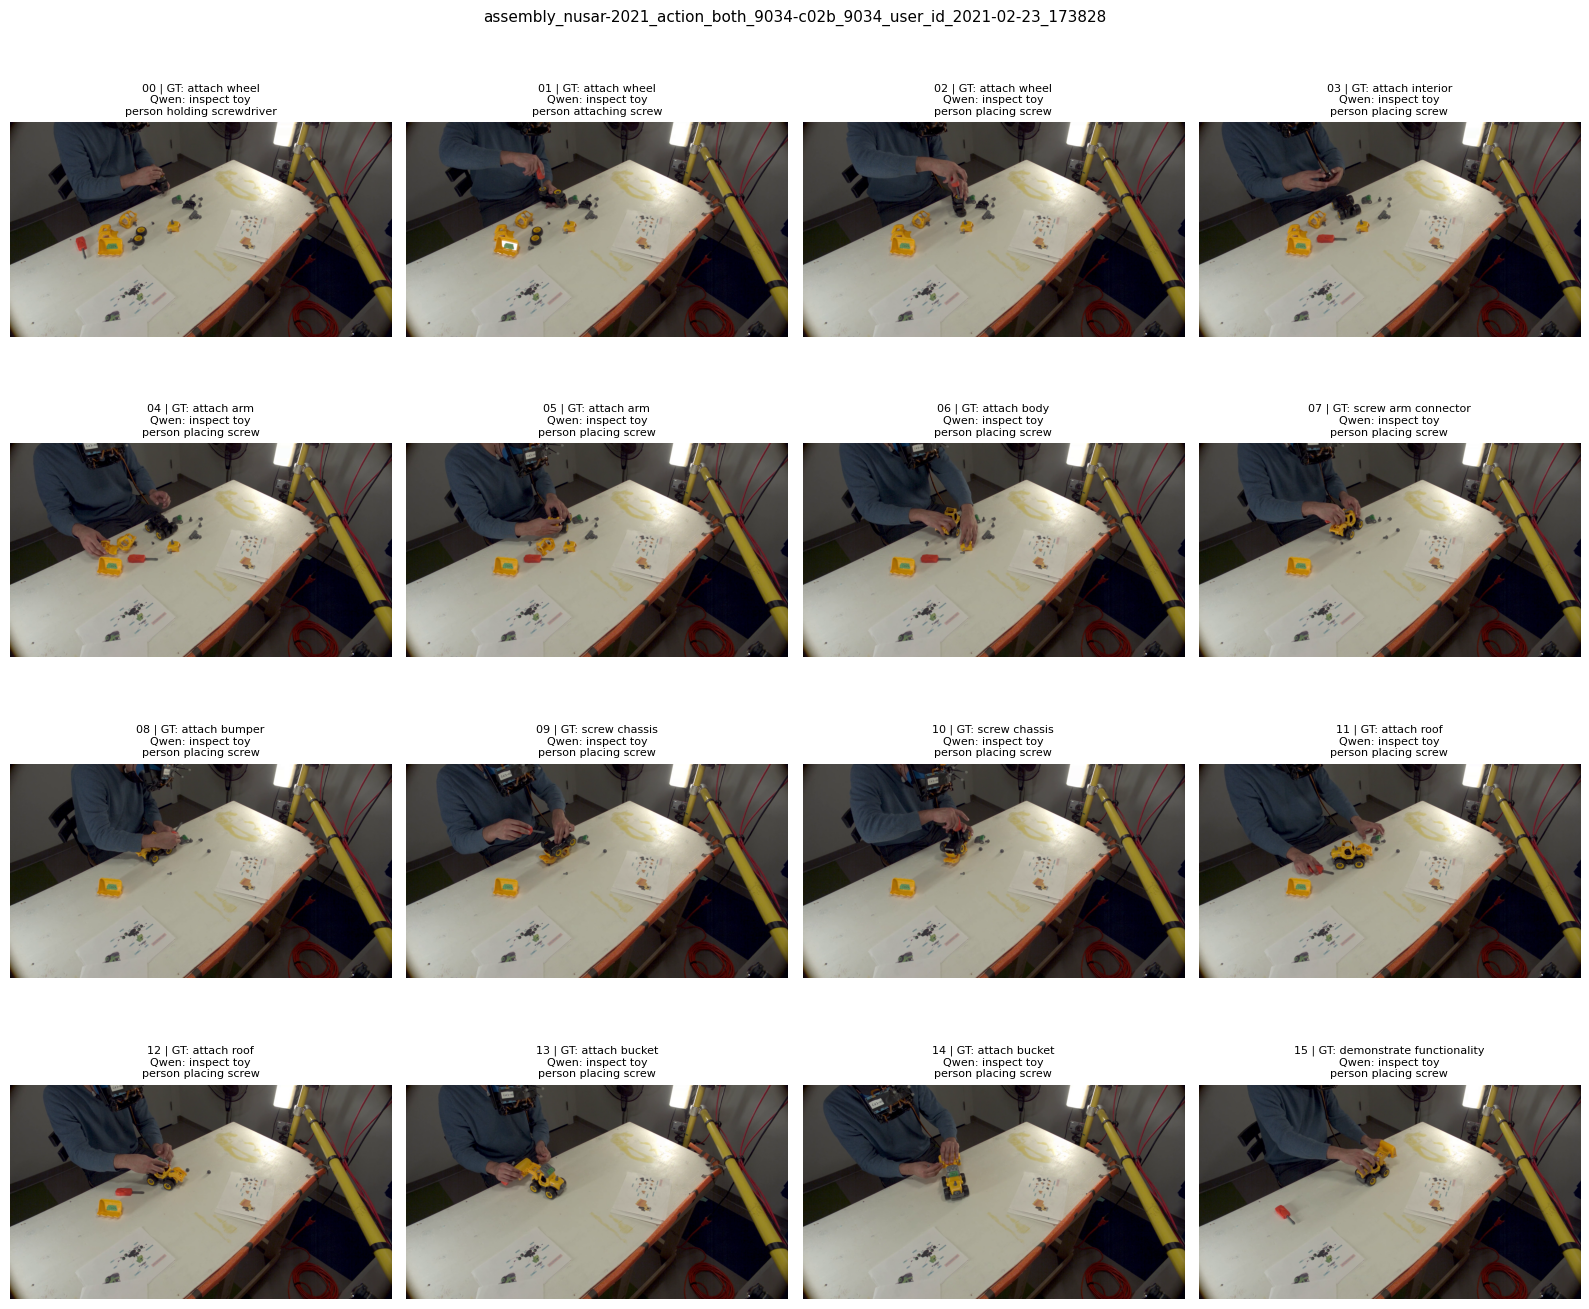

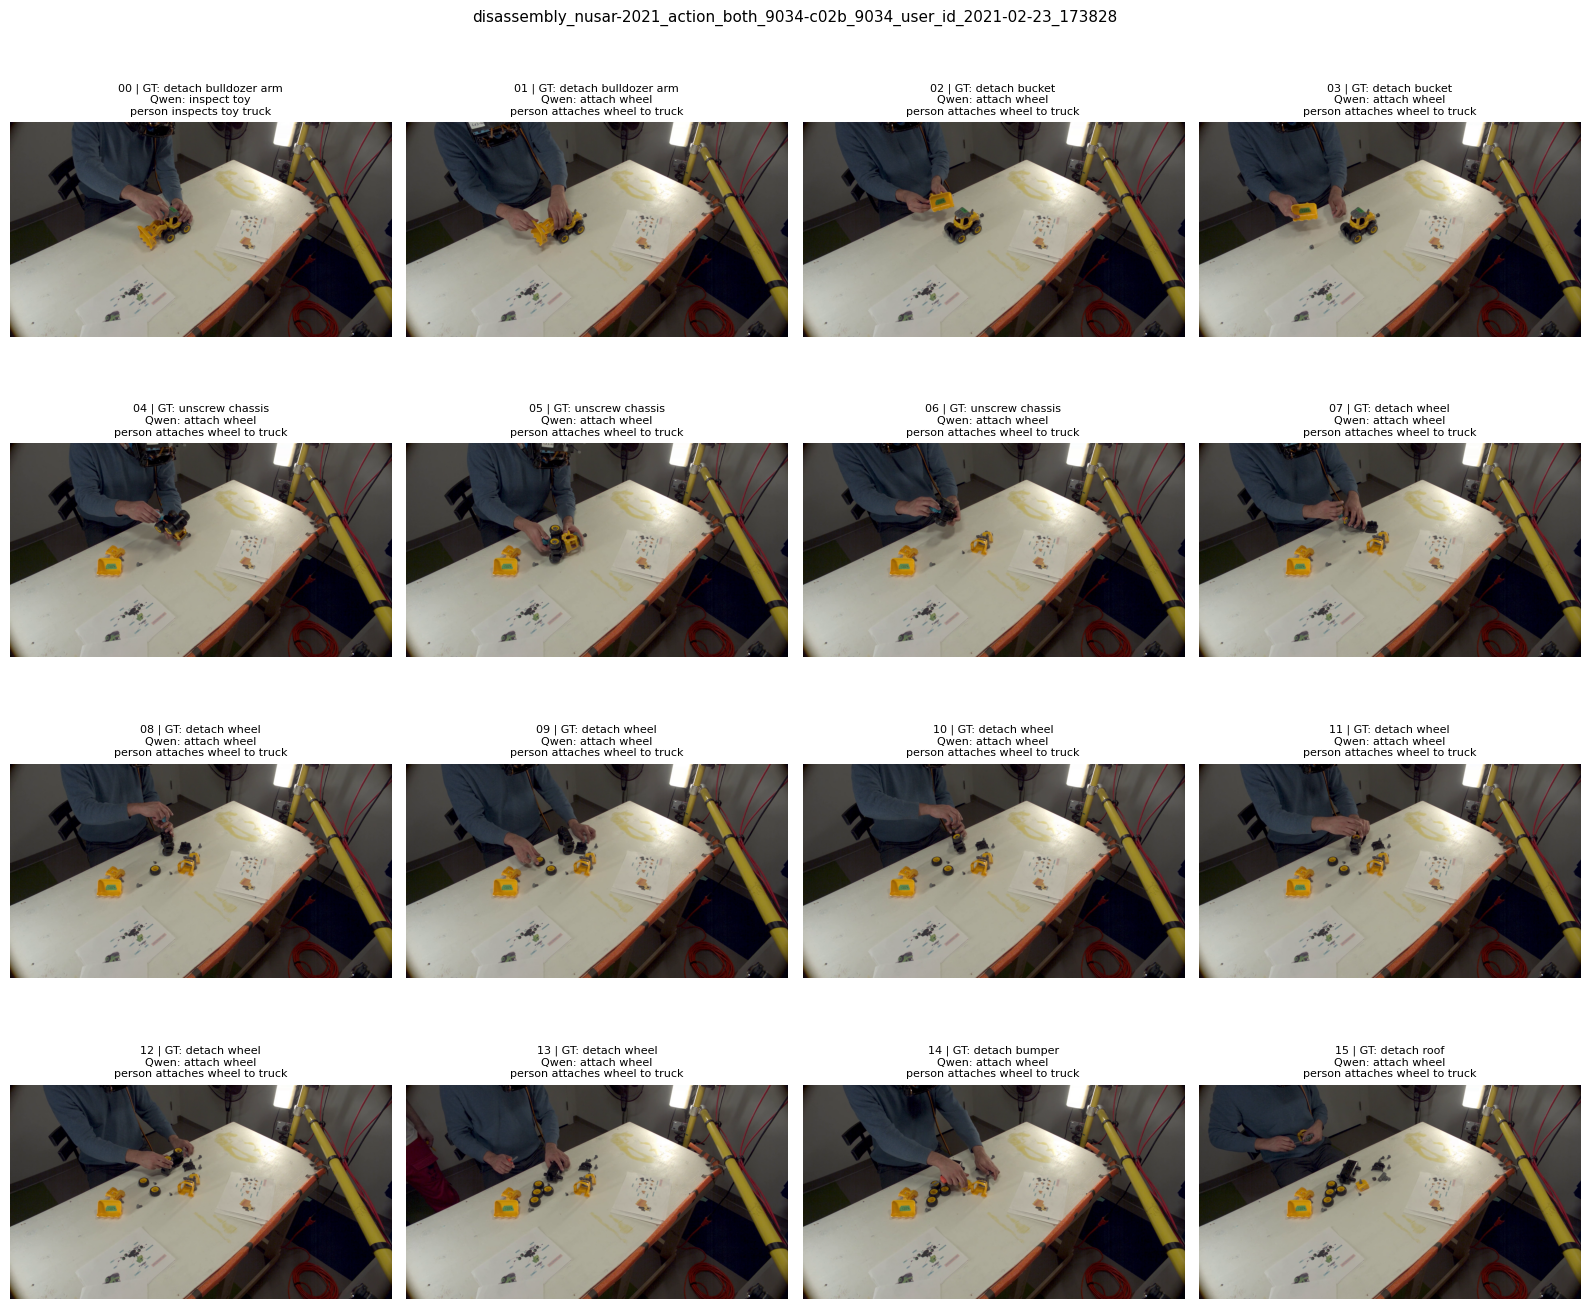

Exact-frame cohorts prepared: ['assembly_nusar-2021_action_both_9034-c02b_9034_user_id_2021-02-23_173828', 'disassembly_nusar-2021_action_both_9034-c02b_9034_user_id_2021-02-23_173828']


In [12]:
def letterbox_frame(frame, side=FRAME_SIDE):
    image = Image.fromarray(frame).convert("RGB")
    image = ImageOps.contain(image, (side, side), Image.Resampling.LANCZOS)
    canvas = Image.new("RGB", (side, side), color=(0, 0, 0))
    offset = ((side - image.width) // 2, (side - image.height) // 2)
    canvas.paste(image, offset)
    return canvas


def sample_exact_frames(sequence_row):
    sequence_id = str(sequence_row.sequence_id)
    metadata = json.loads(
        (PARSED_PREDICTION_DIR / f"{sequence_id}.json").read_text(
            encoding="utf-8"
        )
    )
    video_path = video_path_by_recording[str(sequence_row.recording_name)]
    reader = VideoReader(str(video_path), ctx=cpu(0))
    fps = float(reader.get_avg_fps())
    total_frames = len(reader)
    expected_times = (
        float(sequence_row.clip_start_seconds)
        + CENTER_POSITIONS
        * (
            float(sequence_row.clip_end_seconds)
            - float(sequence_row.clip_start_seconds)
        )
    )
    indices = np.rint(expected_times * fps).astype(np.int64)
    indices = np.clip(indices, 0, total_frames - 1)
    saved_indices = np.asarray(metadata["frame_indices"], dtype=np.int64)
    if not np.array_equal(indices, saved_indices):
        raise RuntimeError(
            f"Recomputed frame indices do not match notebook 24 for {sequence_id}."
        )
    frames = reader.get_batch(indices.tolist()).asnumpy()

    sequence_dir = TEMP_FRAME_ROOT / sequence_id
    if sequence_dir.exists():
        shutil.rmtree(sequence_dir)
    sequence_dir.mkdir(parents=True, exist_ok=True)
    frame_paths = []
    for step_index, frame in enumerate(frames):
        frame_path = sequence_dir / f"frame_{step_index:02d}.jpg"
        letterbox_frame(frame).save(
            frame_path,
            format="JPEG",
            quality=JPEG_QUALITY,
            optimize=True,
        )
        frame_paths.append(frame_path)
    return metadata, frames, frame_paths


visual_inputs = {}
for row in visual_audit_sequences.itertuples(index=False):
    metadata, frames, frame_paths = sample_exact_frames(row)
    sequence_id = str(row.sequence_id)
    gt_labels = read_nonempty_lines(GT_DIR / f"{sequence_id}.txt")
    steps = sorted(metadata["steps"], key=lambda item: int(item["step"]))

    figure, axes = plt.subplots(4, 4, figsize=(16, 14))
    for index, axis in enumerate(axes.flat):
        axis.imshow(frames[index])
        caption = str(steps[index].get("caption", ""))
        predicted = str(steps[index].get("action_cls", "unresolved"))
        axis.set_title(
            f"{index:02d} | GT: {gt_labels[index]}\n"
            f"Qwen: {predicted}\n{caption}",
            fontsize=8,
        )
        axis.axis("off")
    figure.suptitle(sequence_id, fontsize=11)
    figure.tight_layout(rect=[0, 0, 1, 0.98])
    montage_path = ARTIFACT_ROOT / f"{sequence_id}_exact_frames.png"
    figure.savefig(montage_path, dpi=160, bbox_inches="tight")
    plt.show()

    visual_inputs[sequence_id] = {
        "metadata": metadata,
        "frames": frames,
        "frame_paths": frame_paths,
        "montage_path": montage_path,
    }

print("Exact-frame cohorts prepared:", list(visual_inputs))


## 13. Load Qwen3.5-2B with the notebook-24 processor settings

The core audit uses the `ordered_images` representation that notebook 24
actually used. A separate optional check also attempts the video-frame
list API and records its success or error without changing the decision.


In [13]:
torch.cuda.empty_cache()
gc.collect()

processor = AutoProcessor.from_pretrained(
    QWEN_MODEL_ID,
    max_image_size={"longest_edge": PROCESSOR_MAX_IMAGE_PIXELS},
)
processor.tokenizer.padding_side = "left"

model = AutoModelForMultimodalLM.from_pretrained(
    QWEN_MODEL_ID,
    dtype=MODEL_DTYPE,
    device_map="auto",
    low_cpu_mem_usage=True,
    attn_implementation="sdpa",
)
model.eval()
MODEL_DEVICE = next(model.parameters()).device

print("Model device:", MODEL_DEVICE)
print("Parameters:", f"{sum(p.numel() for p in model.parameters()) / 1e9:.3f} B")
print("Allocated:", f"{torch.cuda.memory_allocated() / 1024**3:.2f} GiB")


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/7.75k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.91k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/64.5k [00:00<?, ?B/s]

model.safetensors-00001-of-00001.safeten(…): reconstructing file:   0%|          |  0.00B / 4.55GB            

model.safetensors-00001-of-00001.safeten(…): downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/617 [00:00<?, ?it/s]

Model device: cuda:0
Parameters: 2.213 B
Allocated: 4.12 GiB


## 14. Inspect the exact tensors produced by the processor


In [14]:
def build_messages(frame_paths, prompt, media_mode="ordered_images"):
    if media_mode == "ordered_images":
        visual_content = [
            {"type": "image", "path": str(path)} for path in frame_paths
        ]
    elif media_mode == "video_frame_list":
        visual_content = [
            {
                "type": "video",
                "path": [str(path) for path in frame_paths],
            }
        ]
    else:
        raise ValueError(f"Unknown media mode: {media_mode}")
    return [
        {
            "role": "user",
            "content": visual_content
            + [{"type": "text", "text": prompt}],
        }
    ]


def apply_processor(frame_paths, prompt, media_mode="ordered_images"):
    kwargs = {
        "add_generation_prompt": True,
        "tokenize": True,
        "return_dict": True,
        "return_tensors": "pt",
    }
    if media_mode == "video_frame_list":
        kwargs["video_load_backend"] = "decord"
    messages = build_messages(frame_paths, prompt, media_mode)
    inputs = processor.apply_chat_template(messages, **kwargs)
    return messages, inputs


processor_rows = []
processor_inputs = {}
for sequence_id, item in visual_inputs.items():
    messages, inputs = apply_processor(
        item["frame_paths"], original_prompt, "ordered_images"
    )
    processor_inputs[sequence_id] = inputs
    for key, value in inputs.items():
        shape = list(value.shape) if hasattr(value, "shape") else None
        dtype = str(value.dtype) if hasattr(value, "dtype") else type(value).__name__
        processor_rows.append(
            {
                "sequence_id": sequence_id,
                "media_mode": "ordered_images",
                "input_key": key,
                "shape": json.dumps(shape),
                "dtype": dtype,
            }
        )

processor_df = pd.DataFrame(processor_rows)
processor_df.to_csv(OUT_ROOT / "processor_tensor_inventory.csv", index=False)
display(processor_df)

image_count_evidence = []
for sequence_id, inputs in processor_inputs.items():
    grid_candidates = [
        (key, value)
        for key, value in inputs.items()
        if "image" in key.lower() and "grid" in key.lower()
        and hasattr(value, "shape")
    ]
    if grid_candidates:
        grid_key, grid_value = grid_candidates[0]
        observed_images = int(grid_value.shape[0])
        evidence = f"{grid_key}.shape[0]"
    else:
        list_candidates = [
            (key, value)
            for key, value in inputs.items()
            if "image" in key.lower() and isinstance(value, (list, tuple))
        ]
        if list_candidates:
            list_key, list_value = list_candidates[0]
            observed_images = len(list_value)
            evidence = f"len({list_key})"
        else:
            observed_images = None
            evidence = "no count-bearing image tensor found"
    image_count_evidence.append(
        {
            "sequence_id": sequence_id,
            "expected_images": NUM_TEMPORAL_STEPS,
            "observed_images": observed_images,
            "evidence": evidence,
            "passed": observed_images == NUM_TEMPORAL_STEPS,
        }
    )

image_count_df = pd.DataFrame(image_count_evidence)
image_count_df.to_csv(OUT_ROOT / "processor_image_count_evidence.csv", index=False)
processor_image_count_passed = bool(image_count_df["passed"].all())
display(image_count_df)

first_sequence_id = next(iter(visual_inputs))
try:
    _, video_mode_inputs = apply_processor(
        visual_inputs[first_sequence_id]["frame_paths"],
        original_prompt,
        "video_frame_list",
    )
    video_frame_list_diagnostic = {
        "status": "success",
        "keys": list(video_mode_inputs.keys()),
        "shapes": {
            key: list(value.shape)
            for key, value in video_mode_inputs.items()
            if hasattr(value, "shape")
        },
    }
except Exception as exc:
    video_frame_list_diagnostic = {
        "status": "failed",
        "error_type": type(exc).__name__,
        "error": str(exc),
    }

(OUT_ROOT / "video_frame_list_diagnostic.json").write_text(
    json.dumps(video_frame_list_diagnostic, indent=2), encoding="utf-8"
)
print("Ordered-images count passed:", processor_image_count_passed)
print("Optional video-frame-list diagnostic:")
print(json.dumps(video_frame_list_diagnostic, indent=2))


,sequence_id,media_mode,input_key,shape,dtype
0,assembly_nusar-2021_action_both_9034-c02b_9034_user_id_2021-02-23_173828,ordered_images,input_ids,"[1, 2803]",torch.int64
1,assembly_nusar-2021_action_both_9034-c02b_9034_user_id_2021-02-23_173828,ordered_images,attention_mask,"[1, 2803]",torch.int64
2,assembly_nusar-2021_action_both_9034-c02b_9034_user_id_2021-02-23_173828,ordered_images,mm_token_type_ids,"[1, 2803]",torch.int64
3,assembly_nusar-2021_action_both_9034-c02b_9034_user_id_2021-02-23_173828,ordered_images,pixel_values,"[4096, 1536]",torch.float32
4,assembly_nusar-2021_action_both_9034-c02b_9034_user_id_2021-02-23_173828,ordered_images,image_grid_thw,"[16, 3]",torch.int64
5,disassembly_nusar-2021_action_both_9034-c02b_9034_user_id_2021-02-23_173828,ordered_images,input_ids,"[1, 2803]",torch.int64
6,disassembly_nusar-2021_action_both_9034-c02b_9034_user_id_2021-02-23_173828,ordered_images,attention_mask,"[1, 2803]",torch.int64
7,disassembly_nusar-2021_action_both_9034-c02b_9034_user_id_2021-02-23_173828,ordered_images,mm_token_type_ids,"[1, 2803]",torch.int64
8,disassembly_nusar-2021_action_both_9034-c02b_9034_user_id_2021-02-23_173828,ordered_images,pixel_values,"[4096, 1536]",torch.float32
9,disassembly_nusar-2021_action_both_9034-c02b_9034_user_id_2021-02-23_173828,ordered_images,image_grid_thw,"[16, 3]",torch.int64


,sequence_id,expected_images,observed_images,evidence,passed
0,assembly_nusar-2021_action_both_9034-c02b_9034_user_id_2021-02-23_173828,16,16,image_grid_thw.shape[0],True
1,disassembly_nusar-2021_action_both_9034-c02b_9034_user_id_2021-02-23_173828,16,16,image_grid_thw.shape[0],True


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Keyword argument `video_load_backend` is not a valid argument for this processor and will be ignored.


Ordered-images count passed: True
Optional video-frame-list diagnostic:
{
  "status": "failed",
  "error_type": "ValueError",
  "error": "Sampling frames from a list of images is not supported! Set `do_sample_frames=False`."
}


## 15. Deterministic visual counterfactuals

For one frozen sequence we run the original prompt under three visual
conditions: the true chronological frames, the same frames in reverse
order, and 16 black frames. If real and black inputs produce materially
identical output, the visual path is not functioning as intended.
Different output is necessary evidence that Qwen consumes the images,
though it does not prove that the captions are accurate.


In [15]:
def generate_from_frames(frame_paths, prompt):
    _, inputs = apply_processor(frame_paths, prompt, "ordered_images")
    inputs = inputs.to(MODEL_DEVICE)
    input_tokens = int(inputs["input_ids"].shape[-1])
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    started = time.perf_counter()
    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            use_cache=True,
            pad_token_id=processor.tokenizer.eos_token_id,
        )
    torch.cuda.synchronize()
    continuation = generated_ids[:, input_tokens:]
    raw_text = processor.batch_decode(
        continuation,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0].strip()
    return {
        "raw_text": raw_text,
        "input_tokens": input_tokens,
        "output_tokens": int(continuation.shape[-1]),
        "generation_seconds": float(time.perf_counter() - started),
    }


def extract_first_json_object(text):
    decoder = json.JSONDecoder()
    for start_index, character in enumerate(text):
        if character != "{":
            continue
        try:
            value, _ = decoder.raw_decode(text[start_index:])
            if isinstance(value, dict):
                return value
        except json.JSONDecodeError:
            continue
    return None


audit_sequence_id = first_sequence_id
actual_paths = list(visual_inputs[audit_sequence_id]["frame_paths"])
black_dir = TEMP_FRAME_ROOT / audit_sequence_id / "black"
black_dir.mkdir(parents=True, exist_ok=True)
black_paths = []
for index in range(NUM_TEMPORAL_STEPS):
    path = black_dir / f"black_{index:02d}.jpg"
    Image.new("RGB", (FRAME_SIDE, FRAME_SIDE), (0, 0, 0)).save(
        path, format="JPEG", quality=JPEG_QUALITY
    )
    black_paths.append(path)

conditions = {
    "actual": actual_paths,
    "reversed": list(reversed(actual_paths)),
    "black": black_paths,
}
counterfactual_results = {}
parsed_rows = []

for condition, frame_paths in conditions.items():
    print(f"Generating condition: {condition}")
    result = generate_from_frames(frame_paths, original_prompt)
    raw_path = COUNTERFACTUAL_ROOT / f"{audit_sequence_id}_{condition}.txt"
    raw_path.write_text(result["raw_text"], encoding="utf-8")
    payload = extract_first_json_object(result["raw_text"])
    parsed_steps = payload.get("steps", []) if isinstance(payload, dict) else []
    valid_step_count = len(parsed_steps) == NUM_TEMPORAL_STEPS
    for step in parsed_steps:
        parsed_rows.append(
            {
                "condition": condition,
                "step": step.get("step"),
                "caption": step.get("caption"),
                "label_id": step.get("label_id"),
                "label": step.get("label"),
            }
        )
    counterfactual_results[condition] = {
        "sha256": hashlib.sha256(
            result["raw_text"].encode("utf-8")
        ).hexdigest(),
        "raw_path": str(raw_path),
        "input_tokens": result["input_tokens"],
        "output_tokens": result["output_tokens"],
        "generation_seconds": result["generation_seconds"],
        "valid_16_step_json": valid_step_count,
        "steps": parsed_steps,
    }

parsed_counterfactual_df = pd.DataFrame(parsed_rows)
parsed_counterfactual_df.to_csv(
    COUNTERFACTUAL_ROOT / "parsed_counterfactual_steps.csv", index=False
)

actual_text = Path(
    counterfactual_results["actual"]["raw_path"]
).read_text(encoding="utf-8")
black_text = Path(
    counterfactual_results["black"]["raw_path"]
).read_text(encoding="utf-8")
reversed_text = Path(
    counterfactual_results["reversed"]["raw_path"]
).read_text(encoding="utf-8")

actual_black_similarity = difflib.SequenceMatcher(
    None, actual_text, black_text
).ratio()
actual_reversed_similarity = difflib.SequenceMatcher(
    None, actual_text, reversed_text
).ratio()

def normalized_step_values(result, key):
    steps = result.get("steps", [])
    if len(steps) != NUM_TEMPORAL_STEPS:
        return None
    return [" ".join(str(step.get(key, "")).split()) for step in steps]


actual_captions = normalized_step_values(counterfactual_results["actual"], "caption")
black_captions = normalized_step_values(counterfactual_results["black"], "caption")
actual_labels = normalized_step_values(counterfactual_results["actual"], "label")
black_labels = normalized_step_values(counterfactual_results["black"], "label")

if actual_captions is not None and black_captions is not None:
    changed_caption_fraction = float(
        np.mean(np.asarray(actual_captions) != np.asarray(black_captions))
    )
    changed_label_fraction = float(
        np.mean(np.asarray(actual_labels) != np.asarray(black_labels))
    )
    vision_sensitivity_passed = bool(
        counterfactual_results["actual"]["sha256"]
        != counterfactual_results["black"]["sha256"]
        and (
            changed_caption_fraction >= 0.25
            or changed_label_fraction >= 0.125
        )
    )
else:
    changed_caption_fraction = None
    changed_label_fraction = None
    vision_sensitivity_passed = bool(actual_black_similarity < 0.98)

order_sensitivity_observed = bool(
    counterfactual_results["actual"]["sha256"]
    != counterfactual_results["reversed"]["sha256"]
)

saved_raw_path = Path(
    visual_inputs[audit_sequence_id]["metadata"].get("raw_response_path", "")
)
if saved_raw_path.exists():
    saved_n24_text = saved_raw_path.read_text(encoding="utf-8")
    regeneration_similarity = difflib.SequenceMatcher(
        None, actual_text, saved_n24_text
    ).ratio()
else:
    regeneration_similarity = None

counterfactual_summary = {
    "sequence_id": audit_sequence_id,
    "actual_vs_black_similarity": actual_black_similarity,
    "actual_vs_reversed_similarity": actual_reversed_similarity,
    "changed_caption_fraction_actual_vs_black": changed_caption_fraction,
    "changed_label_fraction_actual_vs_black": changed_label_fraction,
    "vision_sensitivity_passed": vision_sensitivity_passed,
    "order_sensitivity_observed": order_sensitivity_observed,
    "actual_vs_saved_notebook24_similarity": regeneration_similarity,
    "conditions": {
        key: {
            field: value
            for field, value in result.items()
            if field != "steps"
        }
        for key, result in counterfactual_results.items()
    },
}
(OUT_ROOT / "counterfactual_summary.json").write_text(
    json.dumps(counterfactual_summary, indent=2), encoding="utf-8"
)
print(json.dumps(counterfactual_summary, indent=2))


Generating condition: actual
Generating condition: reversed
Generating condition: black
{
  "sequence_id": "assembly_nusar-2021_action_both_9034-c02b_9034_user_id_2021-02-23_173828",
  "actual_vs_black_similarity": 0.03314121037463977,
  "actual_vs_reversed_similarity": 0.2800453514739229,
  "changed_caption_fraction_actual_vs_black": 1.0,
  "changed_label_fraction_actual_vs_black": 0.9375,
  "vision_sensitivity_passed": true,
  "order_sensitivity_observed": true,
  "actual_vs_saved_notebook24_similarity": 1.0,
  "conditions": {
    "actual": {
      "sha256": "28a8f3bd875845fa49eb8eff97b9610fadef6e71f51b208ee4cc30ae41d7f92e",
      "raw_path": "/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/27_qwen_visual_input_integrity_audit/counterfactuals/assembly_nusar-2021_action_both_9034-c02b_9034_user_id_2021-02-23_173828_actual.txt",
      "input_tokens": 2803,
      "output_tokens": 507,
      "generation_seconds":

## 16. Automatic diagnosis and notebook-level repair plan


In [16]:
if not structural_passed:
    recommended_action = "repair_notebook24_metadata_or_completion_state"
    notebooks_to_fix = [24, 25, 26]
    diagnosis = "Notebook 24 saved artifacts are structurally inconsistent."
elif not temporal_alignment_passed:
    recommended_action = "fix_notebook15_24_temporal_alignment_then_rerun_downstream"
    notebooks_to_fix = [15, 24, 25, 26]
    diagnosis = "Notebook 15 and notebook 24 disagree about temporal positions."
elif not frame_index_passed:
    recommended_action = "fix_notebook24_frame_sampling_then_rerun_downstream"
    notebooks_to_fix = [24, 25, 26]
    diagnosis = "Notebook 24 stored frame indices do not match its declared sampling rule."
elif not mapping_passed:
    recommended_action = "fix_mapping_in_notebooks15_18_24_then_rerun_downstream"
    notebooks_to_fix = [15, 18, 24, 25, 26]
    diagnosis = "Class IDs and Assembly101 action strings are inconsistent."
elif not processor_image_count_passed:
    recommended_action = "fix_notebook24_multimodal_packaging_then_rerun_downstream"
    notebooks_to_fix = [24, 25, 26]
    diagnosis = "The Qwen processor did not expose all 16 ordered images."
elif not vision_sensitivity_passed:
    recommended_action = "fix_notebook24_visual_input_path_then_rerun_downstream"
    notebooks_to_fix = [24, 25, 26]
    diagnosis = "Qwen output is not materially sensitive to real versus black frames."
elif shift_alert:
    recommended_action = "inspect_notebook24_frame_order_or_indexing_then_rerun_downstream"
    notebooks_to_fix = [24, 25, 26]
    diagnosis = "A non-zero temporal shift improves hard-label accuracy by over 3 points."
else:
    recommended_action = (
        "pipeline_integrity_passed_keep_notebooks15_18_24_25_26_"
        "and_test_a_stronger_vlm_or_noise_robust_fusion_in_a_new_notebook"
    )
    notebooks_to_fix = []
    diagnosis = (
        "No pipeline-integrity error was found. The weak result is most "
        "consistent with caption/class quality and a teacher that is not "
        "robust to noisy inference-time text."
    )

core_checks = {
    "structural_passed": structural_passed,
    "temporal_alignment_passed": temporal_alignment_passed,
    "frame_index_passed": frame_index_passed,
    "mapping_passed": mapping_passed,
    "processor_image_count_passed": processor_image_count_passed,
    "vision_sensitivity_passed": vision_sensitivity_passed,
    "no_material_shift_alert": not shift_alert,
}
pipeline_integrity_passed = bool(all(core_checks.values()))

final_report = {
    "status": "completed",
    "task": "Assembly101 Qwen visual-input integrity audit",
    "data": {
        "split": TARGET_SPLIT,
        "num_sequences_structurally_audited": int(len(audit_df)),
        "num_visual_sequences": int(len(visual_inputs)),
        "test_accessed": TEST_ACCESSED,
    },
    "source": {
        "qwen_model_id": QWEN_MODEL_ID,
        "qwen_prompt_sha256": prompt_sha256,
        "assembly101_revision": PINNED_REVISION,
        "notebook24_regenerated_full_split": False,
    },
    "core_checks": core_checks,
    "pipeline_integrity_passed": pipeline_integrity_passed,
    "diagnosis": diagnosis,
    "recommended_action": recommended_action,
    "notebooks_to_fix": notebooks_to_fix,
    "rerun_order_if_fixing": notebooks_to_fix,
    "structural_temporal_summary": structural_summary,
    "shift_summary": shift_summary,
    "counterfactual_summary": counterfactual_summary,
    "optional_video_frame_list_diagnostic": video_frame_list_diagnostic,
    "artifacts": {
        "structural_temporal_csv": str(audit_path),
        "hard_predictions_csv": str(prediction_path),
        "shift_sweep_csv": str(OUT_ROOT / "temporal_shift_sweep.csv"),
        "shift_figure": str(shift_figure_path),
        "processor_tensor_inventory_csv": str(
            OUT_ROOT / "processor_tensor_inventory.csv"
        ),
        "processor_image_count_csv": str(
            OUT_ROOT / "processor_image_count_evidence.csv"
        ),
        "visual_selection_csv": str(visual_selection_path),
        "counterfactual_directory": str(COUNTERFACTUAL_ROOT),
    },
    "created_utc": datetime.now(timezone.utc).isoformat(),
}

final_report_path = OUT_ROOT / "final_integrity_report.json"
final_report_path.write_text(
    json.dumps(final_report, indent=2), encoding="utf-8"
)

decision_table = pd.DataFrame(
    [
        {"check": key, "passed": value}
        for key, value in core_checks.items()
    ]
)
decision_table.to_csv(OUT_ROOT / "core_check_results.csv", index=False)

print(json.dumps(final_report, indent=2))
display(decision_table)
print("\nRECOMMENDED ACTION:", recommended_action)
print("NOTEBOOKS TO FIX:", notebooks_to_fix or "none")
print("Saved:", final_report_path)


{
  "status": "completed",
  "task": "Assembly101 Qwen visual-input integrity audit",
  "data": {
    "split": "validation",
    "num_sequences_structurally_audited": 120,
    "num_visual_sequences": 2,
    "test_accessed": false
  },
  "source": {
    "qwen_model_id": "Qwen/Qwen3.5-2B",
    "qwen_prompt_sha256": "08047fb92444d9b043a3894ab2c9f91e516a9e466d02e52f67446ed9551701b6",
    "assembly101_revision": "bfc15ea5e3f0bc8f8c232af6c1b45aa137a9d967",
    "notebook24_regenerated_full_split": false
  },
  "core_checks": {
    "structural_passed": true,
    "temporal_alignment_passed": true,
    "frame_index_passed": true,
    "mapping_passed": true,
    "processor_image_count_passed": true,
    "vision_sensitivity_passed": true,
    "no_material_shift_alert": true
  },
  "pipeline_integrity_passed": true,
  "diagnosis": "No pipeline-integrity error was found. The weak result is most consistent with caption/class quality and a teacher that is not robust to noisy inference-time text.",
  "

,check,passed
0,structural_passed,True
1,temporal_alignment_passed,True
2,frame_index_passed,True
3,mapping_passed,True
4,processor_image_count_passed,True
5,vision_sensitivity_passed,True
6,no_material_shift_alert,True



RECOMMENDED ACTION: pipeline_integrity_passed_keep_notebooks15_18_24_25_26_and_test_a_stronger_vlm_or_noise_robust_fusion_in_a_new_notebook
NOTEBOOKS TO FIX: none
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/27_qwen_visual_input_integrity_audit/final_integrity_report.json


## 17. Safe cleanup of audit-only media


In [17]:
cleanup_rows = []
if DELETE_AUDIT_DOWNLOADS:
    for recording_name, record in downloaded_by_audit.items():
        path = Path(record["path"])
        removed = False
        reason = "preexisting_file_preserved"
        if record["downloaded"]:
            if path.exists() and path.stat().st_size == record["expected_size"]:
                path.unlink()
                removed = True
                reason = "audit_download_removed"
            else:
                reason = "size_mismatch_preserved_for_manual_review"
        cleanup_rows.append(
            {
                "recording_name": recording_name,
                "path": str(path),
                "downloaded_by_audit": record["downloaded"],
                "removed": removed,
                "reason": reason,
            }
        )

if TEMP_FRAME_ROOT.exists():
    shutil.rmtree(TEMP_FRAME_ROOT)

cleanup_df = pd.DataFrame(cleanup_rows)
cleanup_df.to_csv(OUT_ROOT / "cleanup_log.csv", index=False)
display(cleanup_df)

del model
del processor
gc.collect()
torch.cuda.empty_cache()


,recording_name,path,downloaded_by_audit,removed,reason
0,nusar-2021_action_both_9034-c02b_9034_user_id_2021-02-23_173828,/content/drive/MyDrive/mmf_tas_lab_data/assembly101/recordings/nusar-2021_action_both_9034-c02b_9034_user_id_2021-02-23_173828/C10095_rgb.mp4,True,True,audit_download_removed
